<table align="center" width=100%>
    <tr>
        <td width="15%">
            <img src="homework.png">
        </td>
        <td>
            <div align="center">
                <font color="#21618C" size=8px>
                    <b> Take-Home <br>(Session 4)
                    </b>
                </font>
            </div>
        </td>
    </tr>
</table>

#### Import the required libraries

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Read the data

Load the csv file and print the first five observations.

In [34]:
# read the data
df_seed = pd.read_csv("seedtype_data.csv")

# display the first five rows of the data
df_seed.head()

,Area,Perimeter,Kernel_len,Kernel_width,Kernelgroove_len,Type
0,12.76,13.38,5.073,3.155,4.830,0.0
1,12.13,13.73,5.394,3.745,5.220,0.0
2,14.86,14.67,NaN,3.258,5.351,0.0
3,15.69,14.75,5.527,3.514,5.046,0.0
4,19.94,16.92,6.675,3.763,6.550,1.0


**The data definition is as follows:** <br>

**Area**: Area of the wheat kernel 

**Perimeter**: Perimeter of the wheat kernel

**Kernel_len**: Length of the wheat kernel

**Kernel_width**: Width of the wheat kernel

**Kernelgroove_len**: Length of the wheat kernel groove

**Type**: Type of the wheat seed (0 = Kama Wheat, 1 = Rosa Wheat) (target/dependent variable)

Our objective is to predict whether the wheat seed is of Kama or Rosa type.

#### EDA 

In [35]:
df_seed.dtypes

Area                float64
Perimeter           float64
Kernel_len          float64
Kernel_width        float64
Kernelgroove_len    float64
Type                float64
dtype: object

In [36]:
df_seed.shape

(202, 6)

In [37]:
df_seed.describe(include=[np.number])

,Area,Perimeter,Kernel_len,Kernel_width,Kernelgroove_len,Type
count,199.000000,199.000000,193.000000,199.000000,199.000000,199.000000
mean,15.476533,14.792261,5.651036,3.471643,5.445779,0.356784
std,2.504142,1.210241,0.445302,0.305630,0.479849,0.480258
min,12.010000,13.010000,4.899000,2.911000,4.649000,0.000000
25%,13.345000,13.690000,5.267000,3.200000,5.059500,0.000000
50%,14.990000,14.670000,5.554000,3.485000,5.275000,0.000000
75%,17.490000,15.885000,6.006000,3.763000,5.879000,1.000000
max,21.180000,17.250000,6.675000,4.033000,6.550000,1.000000


###### As per above output, the value of mean and 505 are close andthe difference between 75% & max is not huge. 
###### As initial observations it appears the dataset doescn't contain extreme values.
###### We can ignore the Variable Type as it is the Categorical Variable with floating values.

In [38]:
df_seed.isnull().sum()

Area                3
Perimeter           3
Kernel_len          9
Kernel_width        3
Kernelgroove_len    3
Type                3
dtype: int64

###### There are missing values, which needs to be imputed.

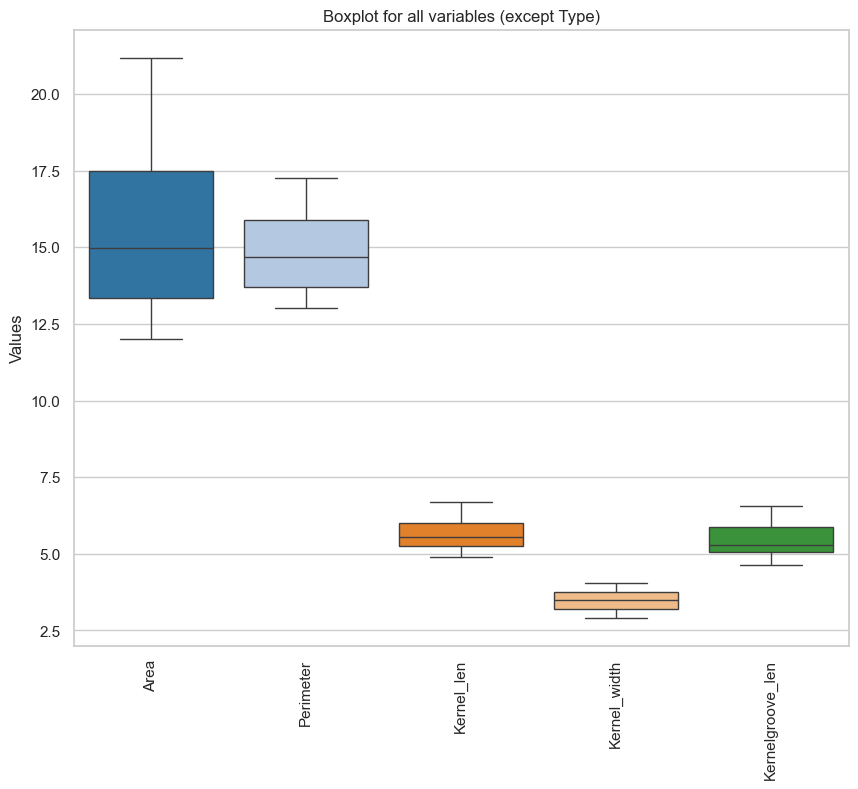

In [39]:
# Visualizing the Distribution of Data

df_features = df_seed.drop(columns=["Type"], errors="ignore")
sns.set(style="whitegrid")
plt.figure(figsize=(10,8))
sns.boxplot(data=df_features,palette="tab20")
plt.title("Boxplot for all variables (except Type)")
plt.ylabel("Values")
plt.xticks(rotation=90)
plt.show()

###### Based on above barplot, we can say none of the variables have outliers. 
###### Therefore we can impute missing value of numerical variables via mean & categorical variable via mode.

In [40]:
# Impute missing values

df_features = df_features.fillna(df_features.mean())

df_seed['Type'] = df_seed['Type'].fillna(df_seed['Type'].mode()[0])

In [41]:
df_features.isnull().sum()

Area                0
Perimeter           0
Kernel_len          0
Kernel_width        0
Kernelgroove_len    0
dtype: int64

In [42]:
df_seed['Type'].isnull().sum()

np.int64(0)

In [43]:
# Build Feature Matrix & Target Vector

X = df_features
y = df_seed['Type']

In [44]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

### Let's begin with some hands-on practice exercises

<table align="left">
    <tr>
        <td width="6%">
            <img src="question_icon.png">
        </td>
        <td>
            <div align="left", style="font-size:120%">
                <font color="#21618C">
                    <b>1. Build a decision tree model using the gini criterion. </b>
                </font>
            </div>
        </td>
    </tr>
</table>

In [45]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# Train Model
model.fit(X_train,y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

In [46]:
# Decision Tree Metrics
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

report = classification_report(y_test, y_pred, target_names=["Type 0", "Type 1"])
print("Classification Report for Decision Tree Model:\n",report)

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy Score of Decision Tree Model:\n", accuracy)


Classification Report for Decision Tree Model:
               precision    recall  f1-score   support

      Type 0       1.00      0.92      0.96        25
      Type 1       0.89      1.00      0.94        16

    accuracy                           0.95        41
   macro avg       0.94      0.96      0.95        41
weighted avg       0.96      0.95      0.95        41

Accuracy Score of Decision Tree Model:
 0.9512195121951219


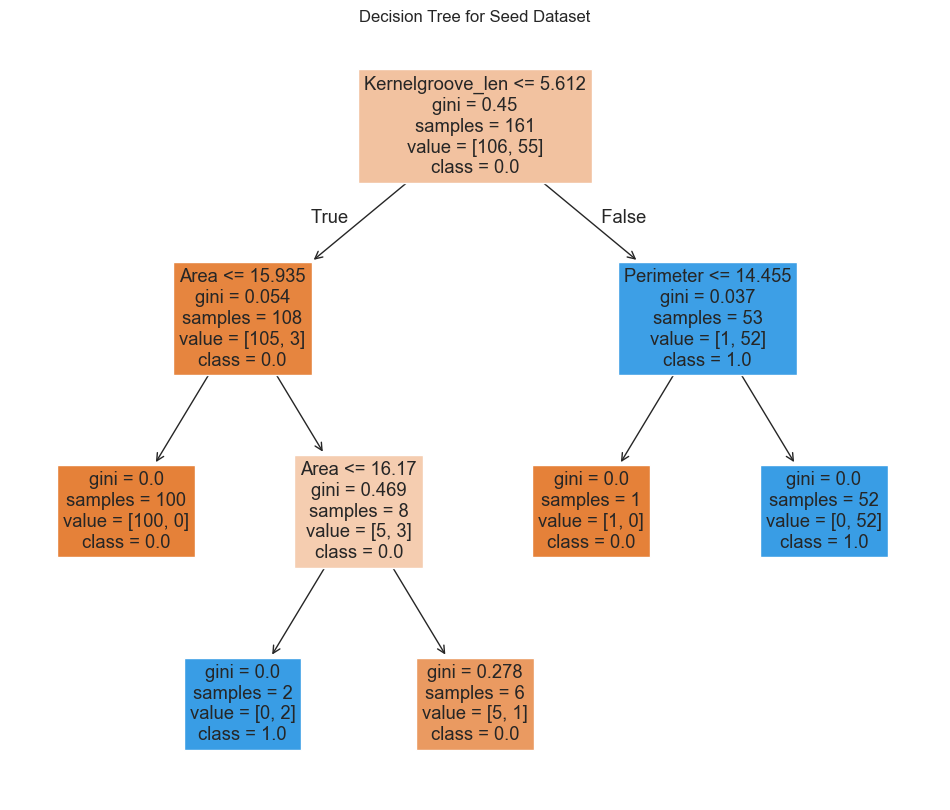

In [47]:
# Visualizing the Decision Tree

plt.figure(figsize=(12,10))
plot_tree(model, feature_names=df_features.columns.astype(str), class_names=df_seed['Type'].unique().astype(str), filled=True)
plt.title("Decision Tree for Seed Dataset")
plt.show()